### **ESTIMACIÓN DEL MODELO DE VALORACIÓN DE ACTIVOS DE CAPITAL CAPM**

Apuntes de: Alejandro Vargas Sanchez, PhD, CFA

alejandro.vargas@upb.edu

**1. Importamos las librerías**

In [ ]:
import pandas as pd
import statistics
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter
from mlxtend.plotting import scatterplotmatrix

**2. Cargamos la serie de tiempo de precios de las acciones**

In [ ]:
df_stock = pd.read_excel('Stock_price.xlsx', sheet_name = 'Stocks',
                   header=0, index_col=0, parse_dates=True,)

In [ ]:
# Mostrar todos los tickers tal como están en el DataFrame
tickers = df_stock.columns.tolist()

print("TICKERS DISPONIBLES:")
print(tickers)

TICKERS DISPONIBLES:
['AAPL.OQ', 'F', 'TSLA.O', 'M', 'MSFT.O', 'MMM', 'T', 'DIS', 'GOOGL.O', 'AMZN.O', 'CAT', 'CSCO.O', 'C', 'DD', 'FDX', 'GM']


In [ ]:
tickers_report = pd.DataFrame({
    'Ticker': tickers
})
tickers_report

,Ticker
0,AAPL.OQ
1,F
2,TSLA.O
3,M
4,MSFT.O
5,MMM
6,T
7,DIS
8,GOOGL.O
9,AMZN.O


In [ ]:
# Elegir un ticker exacto del DataFrame (usa el nombre tal cual aparece)
TICKER = 'MSFT.O'   # 👈 cámbialo por el que necesites

# Crear un DataFrame solo con esa columna
df_single = df_stock[[TICKER]]

**3. Cargamos la serie de tiempo del Índice de mercado**

In [ ]:
df_market = pd.read_excel('SP500.xlsx', sheet_name = 'SP500',
                   header=0, index_col=0, parse_dates=True,)

In [ ]:
# Unir con el índice de mercado (alineado por fecha)
df_general = df_single.join(df_market, how='inner')

# Ver los primeros registros
df_general.head()

,MSFT.O,SP500
Date,,
2020-10-15,219.66,3483.34
2020-10-16,219.66,3483.81
2020-10-19,214.22,3426.92
2020-10-20,214.65,3443.12
2020-10-21,214.80,3435.56


In [ ]:
# Renombrar la columna SP500 a 'Market'
df_general = df_general.rename(columns={'SP500': 'Market'})
df_general.head()

,MSFT.O,Market
Date,,
2020-10-15,219.66,3483.34
2020-10-16,219.66,3483.81
2020-10-19,214.22,3426.92
2020-10-20,214.65,3443.12
2020-10-21,214.80,3435.56


**3. Calculamos los HPR**

Primero acotamos la muestra a periodos mensuales.

Luego calculamos el HPR con los precios de cada mes.

$HPR = \frac{P_1 + D_1 - P_0}{P_0}$

In [ ]:
# Calcular los rendimientos mensuales (returns)
r = (
    df_general
    .resample('ME')        # Cambiar la frecuencia a mensual
    .last()               # Tomar el último valor de cada mes
    .pct_change()         # Calcular rendimientos porcentuales
    .dropna()             # Eliminar valores NaN iniciales
)

# Mostrar las primeras filas
r.head()


,MSFT.O,Market
Date,,
2020-11-30,0.057292,0.107546
2020-12-31,0.039006,0.037121
2021-01-31,0.042892,-0.011137
2021-02-28,0.001811,0.026091
2021-03-31,0.014588,0.042439


Calculamos el coeficiente de correlación entre los rendimientos de las acciones y el índice de mercado.

In [ ]:
corr=r.corr()
corr

,MSFT.O,Market
MSFT.O,1.000000,0.724082
Market,0.724082,1.000000


**4. Graficamos los rendimientos**

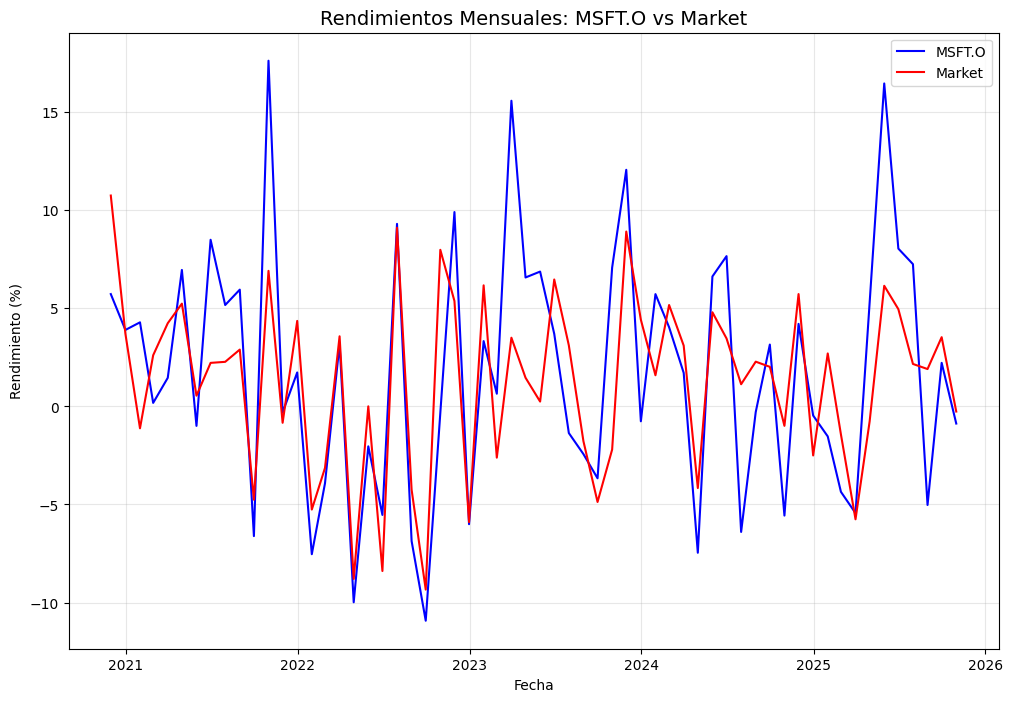

In [ ]:
# Copia para graficar
ru = r.copy()

plt.figure(figsize=(12, 8))
plt.plot(r.index, r[TICKER] * 100, label=TICKER, color='blue')
plt.plot(r.index, r['Market'] * 100, label='Market', color='red')

plt.title(f'Rendimientos Mensuales: {TICKER} vs Market', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Rendimiento (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

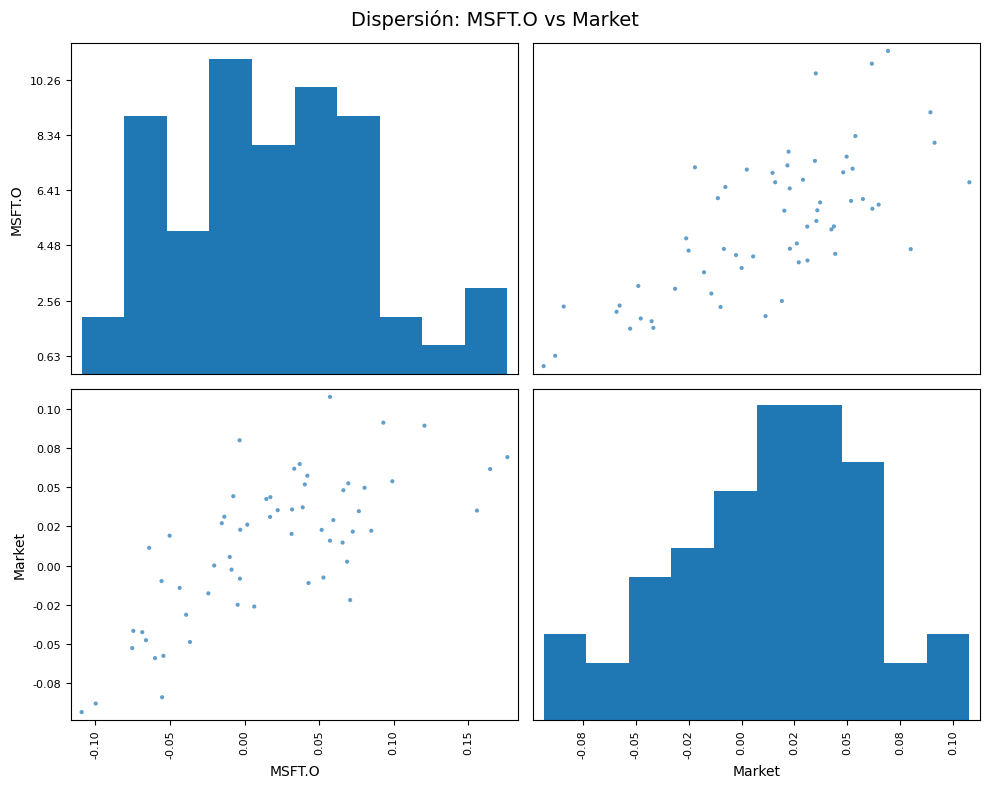

In [ ]:
from matplotlib.ticker import FormatStrFormatter
cols = ['MSFT.O', 'Market']

# Crear la matriz de dispersión
axes = scatter_matrix(r[cols], figsize=(10, 8), alpha=0.7, diagonal='hist')

# Título
plt.suptitle('Dispersión: MSFT.O vs Market', fontsize=14)

# Formatear los ejes para que muestren solo 2 decimales
for ax in axes.flatten():
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

Convertimos la columna del índice a periodos mensuales.

In [ ]:
r.index = r.index.to_period('M')
r.head()

,MSFT.O,Market
Date,,
2020-11,0.057292,0.107546
2020-12,0.039006,0.037121
2021-01,0.042892,-0.011137
2021-02,0.001811,0.026091
2021-03,0.014588,0.042439


**5. Cargamos los datos sobre la tasa libre de riesgo**

In [ ]:
rf = pd.read_excel('3M_TBill.xlsx', sheet_name = 'TBill',
                   header=0, index_col=0, parse_dates=True,)
rf

,3M_US_TBill
Date,
2020-10-15,0.104
2020-10-16,0.096
2020-10-19,0.096
2020-10-20,0.101
2020-10-21,0.096
...,...
2025-10-08,3.944
2025-10-09,3.954
2025-10-10,3.947


In [ ]:
rf = rf['3M_US_TBill']/100/360
rf.name = 'risk_free'
rf=pd.DataFrame(rf)

In [ ]:
rf

,risk_free
Date,
2020-10-15,0.000003
2020-10-16,0.000003
2020-10-19,0.000003
2020-10-20,0.000003
2020-10-21,0.000003
...,...
2025-10-08,0.000110
2025-10-09,0.000110
2025-10-10,0.000110


**6. Importamos el risk kit de AVS**

In [ ]:
import avs_risk_kit_3 as ark

Recalculamos los rendimientos a periodos mensuales.

In [ ]:
rf_m = rf.resample('M').apply(ark.compound).to_period('M')
rf_m.tail()

/tmp/ipython-input-3477059870.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rf_m = rf.resample('M').apply(ark.compound).to_period('M')


,risk_free
Date,
2025-06,0.002411
2025-07,0.002661
2025-08,0.002468
2025-09,0.002341
2025-10,0.001098


In [ ]:
rf_m.head()

,risk_free
Date,
2020-10,0.000032
2020-11,0.000046
2020-12,0.000050
2021-01,0.000042
2021-02,0.000021


**7. Elaboramos una tabla con todos los datos**

In [ ]:
# 1) Pasa r (PeriodIndex) a DatetimeIndex en fin de mes
if isinstance(r.index, pd.PeriodIndex):
    r_idx = r.index.to_timestamp('M')
else:
    r_idx = r.index.to_period('M').to_timestamp('M')

r2 = r.copy()
r2.index = r_idx

# 2) Asegura rf_m también en DatetimeIndex fin de mes
if isinstance(rf_m.index, pd.PeriodIndex):
    rf_m2_idx = rf_m.index.to_timestamp('M')
else:
    rf_m2_idx = rf_m.index.to_period('M').to_timestamp('M')

rf_m2 = rf_m.copy()
rf_m2.index = rf_m2_idx

# 3) Unir en el mismo DataFrame que quieres llamar df_general
df_general = r2.join(rf_m2[['risk_free']].rename(columns={'risk_free': 'Risk free rate'}),
                     how='left')

df_general.head()

,MSFT.O,Market,Risk free rate
Date,,,
2020-11-30,0.057292,0.107546,0.000046
2020-12-31,0.039006,0.037121,0.000050
2021-01-31,0.042892,-0.011137,0.000042
2021-02-28,0.001811,0.026091,0.000021
2021-03-31,0.014588,0.042439,0.000017


**8. Calculamos las primas de riesgo (R) para la empresa y para el índice de mercado**

In [ ]:
df_general['Eq Risk Premium']=(df_general['MSFT.O'] -df_general['Risk free rate'])
df_general['Mkt Risk Premium']=(df_general['Market'] -df_general['Risk free rate'])
df_general.head()

,MSFT.O,Market,Risk free rate,Eq Risk Premium,Mkt Risk Premium
Date,,,,,
2020-11-30,0.057292,0.107546,0.000046,0.057247,0.107500
2020-12-31,0.039006,0.037121,0.000050,0.038956,0.037071
2021-01-31,0.042892,-0.011137,0.000042,0.042850,-0.011179
2021-02-28,0.001811,0.026091,0.000021,0.001790,0.026070
2021-03-31,0.014588,0.042439,0.000017,0.014571,0.042422


**9. Calculamos estadísticas para cada una de las variables**

En base a los rendimientos mensuales.

In [ ]:
descr_stats= df_general.describe()
descr_stats

,MSFT.O,Market,Risk free rate,Eq Risk Premium,Mkt Risk Premium
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,0.017593,0.012968,0.001827,0.015766,0.011141
std,0.063963,0.045379,0.001287,0.063915,0.045348
min,-0.109267,-0.093396,0.000007,-0.111118,-0.095247
25%,-0.027379,-0.015111,0.000145,-0.030678,-0.017695
50%,0.017224,0.021940,0.002439,0.015934,0.019334
75%,0.061113,0.043767,0.002994,0.060388,0.042710
max,0.176291,0.107546,0.003491,0.176263,0.107500


Utilizamos el risk kit de AVS para calcular estadísticas financieras.

In [ ]:
financial_stats=ark.summary_stats(df_general, riskfree_rate=0.03)
financial_stats

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
MSFT.O,0.204548,0.221573,0.261750,2.770266,0.082229,-0.000073,0.766549,-0.309794
Market,0.153269,0.157198,-0.390132,2.709828,0.066175,-0.002946,0.763087,-0.247695
Risk free rate,0.022134,0.004457,-0.437533,1.487447,0.000465,NaN,-1.717608,0.000000
Eq Risk Premium,0.178797,0.221407,0.262706,2.772749,0.083960,0.000277,0.653893,-0.316438
Mkt Risk Premium,0.128532,0.157089,-0.375079,2.703209,0.067771,-0.004331,0.610321,-0.253310


Presentamos un resumen con los rendimientos anualizados.

In [ ]:
annual = ark.annualize_rets(df_general["2020":"2025"], 12)
annual

,0
MSFT.O,0.204548
Market,0.153269
Risk free rate,0.022134
Eq Risk Premium,0.178797
Mkt Risk Premium,0.128532


Preparamos un data frame con las primas de riesgo para la elaboración del modelo econométrico.

In [ ]:
erp=pd.DataFrame(df_general['Eq Risk Premium'])
mrp=pd.DataFrame(df_general['Mkt Risk Premium'])

**10. Realizamos la estimación de los coeficientes mediante OLS**

$R_i(t) = \alpha_i + \beta_i R_M(t) + e_i(t)$

In [ ]:
exp_var =mrp
exp_var["Constant"] = 1
lm = sm.OLS(erp, exp_var).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Eq Risk Premium   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     63.74
Date:                Fri, 17 Oct 2025   Prob (F-statistic):           6.53e-11
Time:                        22:01:42   Log-Likelihood:                 102.62
No. Observations:                  60   AIC:                            -201.2
Df Residuals:                      58   BIC:                            -197.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Mkt Risk Premium     1.0198      0.128      7.984      0.000       0.764       1.276
Constant             0.0044      0.006      0.744      0.460      -0.007       0.016
==============================================================================
Omnibus:                        3.497   Durbin-Watson:                   1.710
Prob(Omnibus):                  0.174   Jarque-Bera (JB):                2.900
Skew:                           0.536   Prob(JB):                        0.235
Kurtosis:                       3.109   Cond. No.                         22.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Corregimos los errores estandar para que sean robustos.

In [ ]:
y = erp.pop('Eq Risk Premium')
X = sm.add_constant(mrp)
capm_model = sm.OLS(y, X).fit(cov_type='HC3')
print(capm_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Eq Risk Premium   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     71.46
Date:                Fri, 17 Oct 2025   Prob (F-statistic):           1.07e-11
Time:                        22:01:44   Log-Likelihood:                 102.62
No. Observations:                  60   AIC:                            -201.2
Df Residuals:                      58   BIC:                            -197.1
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Mkt Risk Premium     1.0198      0.121  

In [ ]:
lm.params

,0
Mkt Risk Premium,1.019837
Constant,0.004405
